Overall  TP:262 FP:25 FN:38  P:0.913  R:0.873  F1:0.893
Entry  TP:136 FP:8 FN:13  P:0.944  R:0.913  F1:0.928
Exit  TP:126 FP:17 FN:25  P:0.881  R:0.834  F1:0.857


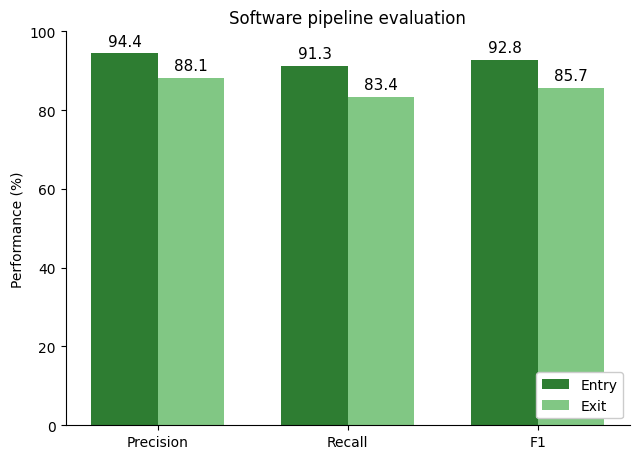

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Load & clean predicted events ─────────────────────────────────────────
pred = pd.read_csv("research_data/mee_predicted_events.csv")
pred["video"] = pred["video_title"].astype(str).str.replace("^cvpr", "", regex=True)
pred["timestamp"] = pd.to_datetime(pred["timestamp"], errors="coerce")
pred["nest"] = pd.to_numeric(pred["nest"], errors="coerce")
pred = pred[["video", "action", "nest", "timestamp"]].dropna().copy()

# ── Load & clean manual events ─────────────────────────────────────────────
manual = pd.read_csv("research_data/mee_manual_events.csv")
manual = manual[["video", "action", "nest", "timestamp"]].dropna().copy()
manual["nest"] = pd.to_numeric(manual["nest"], errors="coerce")
manual["date_str"] = manual["video"].str.extract(r"_(\d{4}-\d{2}-\d{2})_")
manual["timestamp"] = pd.to_datetime(
    manual["date_str"] + " " + manual["timestamp"].astype(str), errors="coerce"
)
manual = manual[["video", "action", "nest", "timestamp"]].dropna().copy()

# ── Matching function ──────────────────────────────────────────────────────
def match_events(pred_df, manual_df, tolerance_sec=2.0):
    pred_df = (pred_df.sort_values(["video", "timestamp"])
               .reset_index(drop=False).rename(columns={"index": "pred_idx"}))
    manual_df = (manual_df.sort_values(["video", "timestamp"])
                 .reset_index(drop=False).rename(columns={"index": "man_idx"}))
    used_pred = set()
    matches   = []
    tol       = pd.Timedelta(seconds=tolerance_sec)

    for _, man_event in manual_df.iterrows():
        candidates = pred_df[
            (pred_df["video"]  == man_event["video"])  &
            (pred_df["action"] == man_event["action"]) &
            (pred_df["nest"]   == man_event["nest"])   &
            (~pred_df["pred_idx"].isin(used_pred))
        ].copy()
        if candidates.empty:
            continue
        candidates["time_diff"] = (candidates["timestamp"] - man_event["timestamp"]).abs()
        candidates = candidates[candidates["time_diff"] <= tol].sort_values("time_diff")
        if not candidates.empty:
            chosen = candidates.iloc[0]
            used_pred.add(chosen["pred_idx"])
            matches.append((man_event["man_idx"], chosen["pred_idx"]))

    tp = len(matches)
    fp = len(pred_df) - tp
    fn = len(manual_df) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return tp, fp, fn, precision, recall, f1

# ── Compute metrics ────────────────────────────────────────────────────────
tp, fp, fn, precision, recall, f1 = match_events(pred, manual, tolerance_sec=2)
print(f"Overall  TP:{tp} FP:{fp} FN:{fn}  P:{precision:.3f}  R:{recall:.3f}  F1:{f1:.3f}")

results = {}
for action in ["Entry", "Exit"]:
    tp_a, fp_a, fn_a, p_a, r_a, f1_a = match_events(
        pred[pred["action"] == action],
        manual[manual["action"] == action],
        tolerance_sec=2
    )
    results[action] = [round(p_a * 100, 1), round(r_a * 100, 1), round(f1_a * 100, 1)]
    print(f"{action}  TP:{tp_a} FP:{fp_a} FN:{fn_a}  P:{p_a:.3f}  R:{r_a:.3f}  F1:{f1_a:.3f}")

# ── Plot ───────────────────────────────────────────────────────────────────
labels = ["Precision", "Recall", "F1"]
x      = np.arange(len(labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(6.5, 4.7))
bars1 = ax.bar(x - width/2, results["Entry"], width, label="Entry", color="#2E7D32")
bars2 = ax.bar(x + width/2, results["Exit"],  width, label="Exit",  color="#81C784")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Performance (%)")
ax.set_ylim(0, 100)
ax.set_title("Software pipeline evaluation")
ax.legend(loc='lower right', frameon=True, edgecolor='#cccccc', framealpha=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1.2,
                f"{val:.1f}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
#plt.savefig("pipeline_performance.pdf", dpi=300, bbox_inches="tight")
#plt.savefig("pipeline_performance.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

TRACKING_CSV   = 'research_data/mee_tracking_data.csv'
MANUAL_CSV     = 'research_data/mee_manual_events.csv'
NESTS_CSV      = 'research_data/mee_nest_bboxes.csv'
OUTPUT_CSV     = 'research_data/mee_lovo_cv_results_with_nests.csv'
FPS            = 30
MATCH_WINDOW_S = 2.0
NEST_PADDING   = 40
RF_PARAMS      = dict(n_estimators=100, max_depth=10, min_samples_split=5,
                      min_samples_leaf=2, random_state=42, class_weight='balanced')


def parse_video_start(video_key):
    parts = video_key.split('_')
    return datetime.strptime(f"{parts[1]} {parts[2]}:{parts[3]}:{parts[4]}", "%Y-%m-%d %H:%M:%S")


def is_inside_bbox(point, bbox, padding=NEST_PADDING):
    x, y = point
    x1, y1, x2, y2 = bbox
    return (x1 - padding <= x <= x2 + padding and y1 - padding <= y <= y2 + padding)


def extract_features(centroids, action, nest_bbox):
    nest_x = (nest_bbox[0] + nest_bbox[2]) / 2
    nest_y = (nest_bbox[1] + nest_bbox[3]) / 2
    path_length = sum(
        np.sqrt((centroids[i+1][0]-centroids[i][0])**2 + (centroids[i+1][1]-centroids[i][1])**2)
        for i in range(len(centroids)-1)
    )
    displacement   = np.sqrt((centroids[-1][0]-centroids[0][0])**2 + (centroids[-1][1]-centroids[0][1])**2)
    tortuosity     = path_length / displacement if displacement > 0 else 0
    speeds         = [np.sqrt((centroids[i+1][0]-centroids[i][0])**2 + (centroids[i+1][1]-centroids[i][1])**2)
                      for i in range(len(centroids)-1)]
    avg_speed      = np.mean(speeds) if speeds else 0
    max_speed      = np.max(speeds)  if speeds else 0
    speed_std      = np.std(speeds)  if speeds else 0
    speed_cv       = speed_std / avg_speed if avg_speed > 0 else 0
    t              = len(speeds) // 3 or 1
    start_speed    = np.mean(speeds[:t])    if speeds else 0
    middle_speed   = np.mean(speeds[t:2*t]) if len(speeds) >= 3 else avg_speed
    end_speed      = np.mean(speeds[-t:])   if speeds else 0
    decel_ratio    = end_speed / start_speed if start_speed > 0 else 1.0
    start_to_nest  = np.sqrt((centroids[0][0]-nest_x)**2  + (centroids[0][1]-nest_y)**2)
    end_to_nest    = np.sqrt((centroids[-1][0]-nest_x)**2 + (centroids[-1][1]-nest_y)**2)
    approach_ratio = end_to_nest / start_to_nest if start_to_nest > 0 else 1.0
    return {
        'trajectory_length': len(centroids), 'path_length': path_length,
        'displacement': displacement, 'tortuosity': tortuosity,
        'avg_speed': avg_speed, 'max_speed': max_speed, 'speed_std': speed_std, 'speed_cv': speed_cv,
        'start_speed': start_speed, 'middle_speed': middle_speed, 'end_speed': end_speed,
        'decel_ratio': decel_ratio, 'start_to_nest': start_to_nest, 'end_to_nest': end_to_nest,
        'approach_ratio': approach_ratio,
        'x_var': np.var([c[0] for c in centroids]), 'y_var': np.var([c[1] for c in centroids]),
        'vertical_movement': centroids[-1][1]-centroids[0][1],
        'horizontal_movement': abs(centroids[-1][0]-centroids[0][0]),
        'is_entry': 1 if action == 'Entry' else 0
    }


def detect_events(vdf, hole_bboxes):
    events = []
    for track_id, group in vdf.groupby('track_id'):
        group = group.sort_values('frame')
        if len(group) < 2:
            continue
        centroids     = list(zip(group['cx'], group['cy']))
        frame_numbers = group['frame'].tolist()
        for nest_id, bbox in hole_bboxes.items():
            if is_inside_bbox(centroids[0], bbox):
                events.append({'action': 'Exit', 'nest': nest_id, 'frame': frame_numbers[0],
                               'track_id': track_id, 'centroids': centroids, 'nest_bbox': bbox})
                break
        for nest_id, bbox in hole_bboxes.items():
            if is_inside_bbox(centroids[-1], bbox):
                events.append({'action': 'Entry', 'nest': nest_id, 'frame': frame_numbers[-1],
                               'track_id': track_id, 'centroids': centroids, 'nest_bbox': bbox})
                break
    return events


def main():
    tracking_df = pd.read_csv(TRACKING_CSV)
    manual_df   = pd.read_csv(MANUAL_CSV, usecols=[0, 1, 2, 3])
    manual_df.columns = ['video', 'action', 'nest', 'timestamp']
    manual_df = manual_df.dropna(subset=['video'])
    nests_df  = pd.read_csv(NESTS_CSV)

    tracking_df['video_key'] = tracking_df['video_title'].str.replace('^cvpr', '', regex=True)
    nests_df['video_key']    = nests_df['video_title'].str.replace('^cvpr', '', regex=True)

    nest_lookup = {
        vk: {int(r['nest_id']): (r['x1'], r['y1'], r['x2'], r['y2']) for _, r in grp.iterrows()}
        for vk, grp in nests_df.groupby('video_key')
    }

    def parse_manual_time(row):
        date_part = row['video'].split('_')[1]
        return datetime.strptime(f"{date_part} {row['timestamp']}", "%Y-%m-%d %H:%M:%S")
    manual_df['dt'] = manual_df.apply(parse_manual_time, axis=1)

    all_features, all_labels, all_groups = [], [], []

    for video_key, vdf in tracking_df.groupby('video_key'):
        if video_key not in nest_lookup:
            print(f"[SKIP] No nest bboxes for {video_key}")
            continue
        events = detect_events(vdf, nest_lookup[video_key])
        try:
            video_start = parse_video_start(video_key)
        except Exception as e:
            print(f"[SKIP] {video_key}: {e}")
            continue
        manual_video = manual_df[manual_df['video'] == video_key]
        for ev in events:
            features   = extract_features(ev['centroids'], ev['action'], ev['nest_bbox'])
            event_time = video_start + timedelta(seconds=ev['frame'] / FPS)
            matched    = any(
                row['action'] == ev['action']
                and int(row['nest']) == ev['nest']
                and abs(event_time - row['dt']) <= timedelta(seconds=MATCH_WINDOW_S)
                for _, row in manual_video.iterrows()
            )
            all_features.append(features)
            all_labels.append(1 if matched else 0)
            all_groups.append(video_key)

    features_df = pd.DataFrame(all_features)
    labels      = np.array(all_labels)
    groups      = np.array(all_groups)

    print(f"Total candidate events : {len(labels)}")
    print(f"  Matched (positive)   : {labels.sum()}")
    print(f"  Noise (negative)     : {(labels==0).sum()}\n")

    cv_results = []
    all_y_true, all_y_pred = [], []

    for held_out in sorted(set(groups)):
        train_mask = groups != held_out
        test_mask  = groups == held_out
        X_train, y_train = features_df[train_mask].values, labels[train_mask]
        X_test,  y_test  = features_df[test_mask].values,  labels[test_mask]

        if len(X_test) == 0 or y_train.sum() < 2 or (y_train == 0).sum() < 2:
            print(f"[SKIP] {held_out} — insufficient training data")
            continue

        clf    = RandomForestClassifier(**RF_PARAMS)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        has_both = len(np.unique(y_test)) > 1
        r = {
            'video':     held_out,
            'n_test':    len(y_test),
            'n_pos':     int(y_test.sum()),
            'precision': precision_score(y_test, y_pred, zero_division=0) if has_both else float('nan'),
            'recall':    recall_score(y_test, y_pred,    zero_division=0) if has_both else float('nan'),
            'f1':        f1_score(y_test, y_pred,         zero_division=0) if has_both else float('nan'),
            'tp': int(((y_pred==1) & (y_test==1)).sum()),
            'fp': int(((y_pred==1) & (y_test==0)).sum()),
            'fn': int(((y_pred==0) & (y_test==1)).sum()),
            'tn': int(((y_pred==0) & (y_test==0)).sum()),
        }
        cv_results.append(r)
        print(f"{held_out:<45}  P={r['precision']:.3f}  R={r['recall']:.3f}  F1={r['f1']:.3f}  "
              f"TP={r['tp']} FP={r['fp']} FN={r['fn']}")

    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    pooled_p   = precision_score(all_y_true, all_y_pred, zero_division=0)
    pooled_r   = recall_score(all_y_true, all_y_pred,    zero_division=0)
    pooled_f1  = f1_score(all_y_true, all_y_pred,         zero_division=0)

    valid   = [r for r in cv_results if not np.isnan(r['f1'])]
    mean_p  = np.mean([r['precision'] for r in valid])
    mean_r  = np.mean([r['recall']    for r in valid])
    mean_f1 = np.mean([r['f1']        for r in valid])
    std_f1  = np.std( [r['f1']        for r in valid])
    min_f1  = min(r['f1'] for r in valid)
    max_f1  = max(r['f1'] for r in valid)

    print(f"\n{'='*60}")
    print(f"POOLED   P:{pooled_p:.3f}  R:{pooled_r:.3f}  F1:{pooled_f1:.3f}")
    print(f"MEAN     P:{mean_p:.3f}  R:{mean_r:.3f}  F1:{mean_f1:.3f} ± {std_f1:.3f}")
    print(f"F1 range {min_f1:.3f} – {max_f1:.3f}")
    tp = sum(r['tp'] for r in cv_results)
    fp = sum(r['fp'] for r in cv_results)
    fn = sum(r['fn'] for r in cv_results)
    tn = sum(r['tn'] for r in cv_results)
    print(f"CONFUSION  TP:{tp}  FP:{fp}  FN:{fn}  TN:{tn}")

    pd.DataFrame(cv_results).to_csv(OUTPUT_CSV, index=False)
    print(f"\nSaved → {OUTPUT_CSV}")


if __name__ == "__main__":
    main()

Total candidate events : 515
  Matched (positive)   : 249
  Noise (negative)     : 266

mendels_2024-04-30_09_00_00                    P=1.000  R=0.889  F1=0.941  TP=8 FP=0 FN=1
mendels_2024-04-30_09_10_01                    P=0.923  R=0.857  F1=0.889  TP=12 FP=1 FN=2
mendels_2024-04-30_09_20_00                    P=0.875  R=1.000  F1=0.933  TP=7 FP=1 FN=0
mendels_2024-04-30_09_30_00                    P=1.000  R=0.882  F1=0.938  TP=15 FP=0 FN=2
mendels_2024-04-30_09_40_01                    P=0.750  R=1.000  F1=0.857  TP=3 FP=1 FN=0
mendels_2024-05-08_15_00_00                    P=0.938  R=0.714  F1=0.811  TP=15 FP=1 FN=6
mendels_2024-05-08_15_30_00                    P=0.955  R=0.913  F1=0.933  TP=21 FP=1 FN=2
mendels_2024-05-08_15_50_00                    P=0.840  R=0.955  F1=0.894  TP=21 FP=4 FN=1
mendels_2024-05-23_12_00_00                    P=0.917  R=0.917  F1=0.917  TP=22 FP=2 FN=2
mendels_2024-05-23_12_40_00                    P=0.962  R=0.981  F1=0.971  TP=51 FP=2 FN=1
mende